# Imports Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet import EfficientNetB0, preprocess_input
from sklearn.utils import class_weight
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset

In [ ]:
DATA_DIR = Path(path)

IMG_SIZE = 224
BATCH_SIZE = 16
SEED = 42

# Load WITHOUT batching
full_ds = tf.keras.preprocessing.image_dataset_from_directory(
    DATA_DIR,
    labels="inferred",
    label_mode="categorical",
    image_size=(IMG_SIZE, IMG_SIZE),
    shuffle=True,
    seed=SEED,
    batch_size=None
)

class_names = full_ds.class_names
num_classes = len(class_names)
print("Classes:", class_names)

Found 1203 files belonging to 4 classes.
Classes: ['clear skin-20251206T143751Z-1-001', 'dark spots-20251206T143751Z-1-001', 'puffy eyes-20251206T143751Z-1-001', 'wrinkles-20251206T143752Z-1-001']


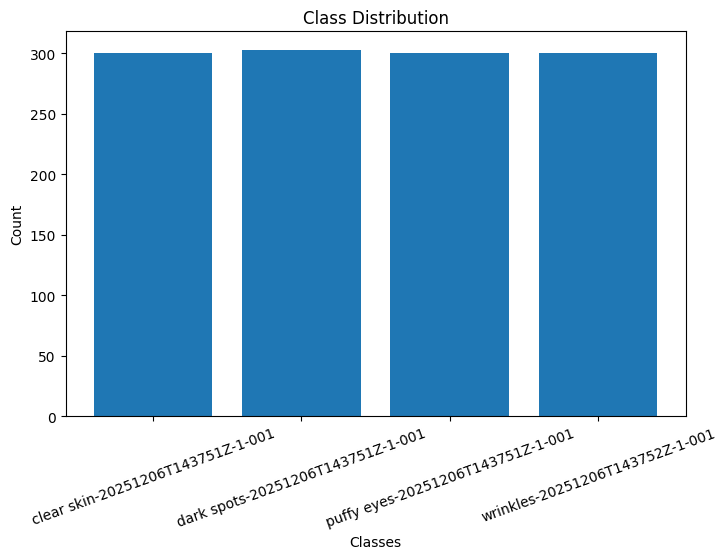

In [ ]:
y_ints = []
for _, y in full_ds:
    y_ints.append(int(tf.argmax(y)))

plt.figure(figsize=(8,5))
unique, counts = np.unique(y_ints, return_counts=True)
plt.bar(class_names, counts)
plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.xticks(rotation=20)
plt.show()

# Train/Val/Test Split

In [ ]:
full_ds = full_ds.shuffle(2000, seed=SEED)

dataset_size = 0
for _ in full_ds:
    dataset_size += 1

train_size = int(0.8 * dataset_size)
val_size   = int(0.1 * dataset_size)

train_ds = full_ds.take(train_size)
remaining = full_ds.skip(train_size)

val_ds = remaining.take(val_size)
test_ds = remaining.skip(val_size)


# Preprocessing + Augmentation + Batching

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.08),
], name="augmentation")

def prepare(ds, training=False):
    if training:
        ds = ds.map(lambda x, y: (data_augmentation(x), y))
    ds = ds.map(lambda x, y: (preprocess_input(x), y))
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds_p = prepare(train_ds, training=True)
val_ds_p   = prepare(val_ds, training=False)
test_ds_p  = prepare(test_ds, training=False)


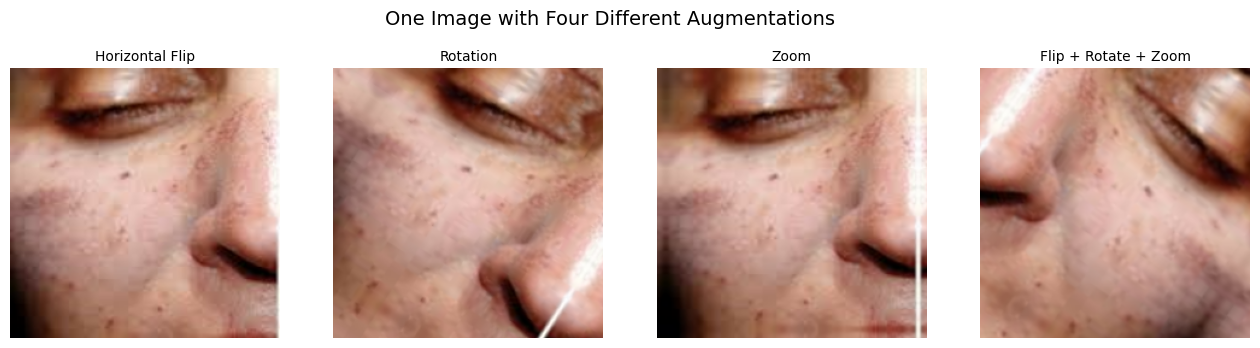

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf

# Get ONE raw image (unbatched)
raw_image = list(train_ds.take(1))[0][0]

# Define specific augmentations (not random)
aug_list = [
    ("Horizontal Flip", layers.RandomFlip("horizontal")),
    ("Rotation", layers.RandomRotation(0.20)),
    ("Zoom", layers.RandomZoom(0.20)),
    ("Flip + Rotate + Zoom", keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15)
    ]))
]

plt.figure(figsize=(16, 4))

for i, (label, aug_layer) in enumerate(aug_list):
    # Expand dims to create batch
    aug_img = aug_layer(tf.expand_dims(raw_image, 0), training=True)[0]

    plt.subplot(1, 4, i + 1)
    plt.imshow(aug_img.numpy().astype("uint8"))
    plt.axis("off")
    plt.title(label, fontsize=10)

plt.suptitle("One Image with Four Different Augmentations", fontsize=14)
plt.show()


# Class Weights

In [ ]:
y_ints = []
for _, y in train_ds:
    y_ints.append(int(tf.argmax(y)))

class_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.arange(num_classes),
    y=y_ints
)
class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(1.0105042016806722), 1: np.float64(1.0020833333333334), 2: np.float64(0.9776422764227642), 3: np.float64(1.0105042016806722)}


# Model Build

In [ ]:
base_model = EfficientNetB0(include_top=False, weights="imagenet",
                            input_shape=(IMG_SIZE, IMG_SIZE, 3), pooling="avg")
base_model.trainable = False

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=["accuracy"]
)

model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,054,695 (15.47 MB)

 Trainable params: 5,124 (20.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [ ]:
callbacks = [
    keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True, monitor="val_accuracy"),
    keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=7, restore_best_weights=True)
]

history1 = model.fit(
    train_ds_p,
    validation_data=val_ds_p,
    epochs=6,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/6
61/61 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.4626 - loss: 1.1758

61/61 ━━━━━━━━━━━━━━━━━━━━ 87s 861ms/step - accuracy: 0.4649 - loss: 1.1722 - val_accuracy: 0.7833 - val_loss: 0.6925
Epoch 2/6
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7697 - loss: 0.6620

61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 286ms/step - accuracy: 0.7696 - loss: 0.6619 - val_accuracy: 0.8167 - val_loss: 0.6015
Epoch 3/6
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 255ms/step - accuracy: 0.8242 - loss: 0.5439 - val_accuracy: 0.7833 - val_loss: 0.6302
Epoch 4/6
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.8379 - loss: 0.5115

61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 279ms/step - accuracy: 0.8379 - loss: 0.5118 - val_accuracy: 0.9000 - val_loss: 0.4231
Epoch 5/6
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 253ms/step - accuracy: 0.8488 - loss: 0.4871 - val_accuracy: 0.8833 - val_loss: 0.4544
Epoch 6/6
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 262ms/step - accuracy: 0.8195 - loss: 0.5210 - val_accuracy: 0.8833 - val_loss: 0.3953


In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.02),
    metrics=["accuracy"]
)

history2 = model.fit(
    train_ds_p,
    validation_data=val_ds_p,
    epochs=25,
    initial_epoch=6,
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 7/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 84s 734ms/step - accuracy: 0.7280 - loss: 0.7680 - val_accuracy: 0.9000 - val_loss: 0.3596
Epoch 8/25
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - accuracy: 0.8740 - loss: 0.4464

61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 282ms/step - accuracy: 0.8736 - loss: 0.4468 - val_accuracy: 0.9167 - val_loss: 0.3196
Epoch 9/25
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.8686 - loss: 0.4181

61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 281ms/step - accuracy: 0.8685 - loss: 0.4178 - val_accuracy: 0.9750 - val_loss: 0.2579
Epoch 10/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 262ms/step - accuracy: 0.9127 - loss: 0.3471 - val_accuracy: 0.9500 - val_loss: 0.2863
Epoch 11/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 267ms/step - accuracy: 0.9300 - loss: 0.3151 - val_accuracy: 0.9500 - val_loss: 0.2313
Epoch 12/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 261ms/step - accuracy: 0.9234 - loss: 0.3053 - val_accuracy: 0.9583 - val_loss: 0.1978
Epoch 13/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 265ms/step - accuracy: 0.9446 - loss: 0.2514 - val_accuracy: 0.9750 - val_loss: 0.1729
Epoch 14/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 261ms/step - accuracy: 0.9494 - loss: 0.2453 - val_accuracy: 0.9750 - val_loss: 0.1596
Epoch 15/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 262ms/step - accuracy: 0.9370 - loss: 0.2503 - val_accuracy: 0.9500 - val_loss: 0.2033
Epoch 16/25
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step - accuracy: 0.9533 - loss: 0.2423

61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 270ms/step - accuracy: 0.9534 - loss: 0.2420 - val_accuracy: 0.9917 - val_loss: 0.1398
Epoch 17/25
60/61 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9520 - loss: 0.2389

61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 276ms/step - accuracy: 0.9524 - loss: 0.2380 - val_accuracy: 1.0000 - val_loss: 0.1404
Epoch 18/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 264ms/step - accuracy: 0.9786 - loss: 0.1987 - val_accuracy: 1.0000 - val_loss: 0.1220
Epoch 19/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 308ms/step - accuracy: 0.9740 - loss: 0.2067 - val_accuracy: 1.0000 - val_loss: 0.1254
Epoch 20/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 261ms/step - accuracy: 0.9770 - loss: 0.1886 - val_accuracy: 0.9917 - val_loss: 0.1254
Epoch 21/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 22s 264ms/step - accuracy: 0.9784 - loss: 0.1774 - val_accuracy: 1.0000 - val_loss: 0.1214
Epoch 22/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 265ms/step - accuracy: 0.9829 - loss: 0.1749 - val_accuracy: 1.0000 - val_loss: 0.1233
Epoch 23/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 19s 263ms/step - accuracy: 0.9720 - loss: 0.1941 - val_accuracy: 1.0000 - val_loss: 0.1234
Epoch 24/25
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 263ms/step - accuracy: 0.9801 - loss: 0.1708 - val_accuracy

# Evaluate Model

In [ ]:
test_loss, test_acc = model.evaluate(test_ds_p)
print("Test Accuracy:", test_acc)


8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 2s/step - accuracy: 0.9946 - loss: 0.1370
Test Accuracy: 0.9917355179786682


# Save the Model

In [ ]:
model.save("efficientnetb0_facial_skin_final.h5")
print("Model saved.")

Model saved.


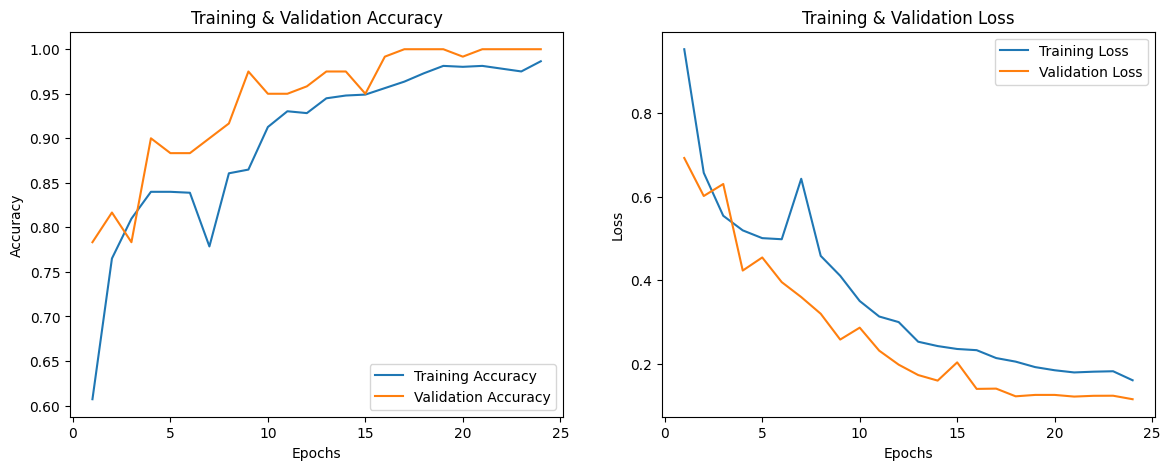

In [ ]:
acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc = history1.history["val_accuracy"] + history2.history["val_accuracy"]
loss = history1.history["loss"] + history2.history["loss"]
val_loss = history1.history["val_loss"] + history2.history["val_loss"]

epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14,5))

# ---- Accuracy ----
plt.subplot(1,2,1)
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training & Validation Accuracy")
plt.legend()

# ---- Loss ----
plt.subplot(1,2,2)
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()

plt.show()

In [ ]:
import cv2
import matplotlib.pyplot as plt

model_path = "/content/best_model.h5"
classes = ["Puffy Eyes", "Dark Spots", "Wrinkles", "Clear Skin"]

image_path = "/content/wrinkles.webp"
predicted_index = 2
predicted_label = classes[predicted_index]
probability = 0.9946

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

h, w, _ = img.shape
x1, y1, x2, y2 = 20, 20, w - 20, h - 20

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")

plt.text(x1, y1 - 15, predicted_label, fontsize=22, fontweight="bold", color="lime")
plt.gca().add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=4))

plt.show()

print("Predicted label:", predicted_label, "with probability", probability)